# Visualize Saved Results

This notebook builds a compact dashboard from saved run metrics and exported prediction-shape reports under `results/`.

In [1]:
import json
import re
from pathlib import Path

import pandas as pd
from matplotlib import pyplot as plt

In [2]:
RESULTS_ROOT = Path("./results")
SHAPE_SUMMARY_PATH = RESULTS_ROOT / "prediction_reports" / "summary_best_prediction_shapes.json"
SUBJECT_PATTERN = re.compile(r"subj(\d{2})_")


def subject_from_name(name: str) -> int | None:
    match = SUBJECT_PATTERN.match(name)
    return int(match.group(1)) if match else None


def load_metrics_rows(results_root: Path) -> list[dict]:
    rows = []
    for metrics_path in sorted(results_root.glob("subj*_*/metrics.json")):
        subject = subject_from_name(metrics_path.parent.name)
        if subject is None:
            continue
        metrics = json.loads(metrics_path.read_text())
        rows.append({"subject": subject, **metrics})
    return rows


def load_shape_rows(summary_path: Path) -> list[dict]:
    if not summary_path.exists():
        print(f"Missing prediction summary: {summary_path}")
        return []
    payload = json.loads(summary_path.read_text())
    rows = []
    for item in payload:
        rows.append(
            {
                "subject": item["subject"],
                "lh_vertices": item["lh_shape"][1],
                "rh_vertices": item["rh_shape"][1],
                "batch_size": item["lh_shape"][0],
                "roi_queries_lh": item["roi_queries"]["lh"],
                "roi_queries_rh": item["roi_queries"]["rh"],
            }
        )
    return rows


metrics_df = pd.DataFrame(load_metrics_rows(RESULTS_ROOT))
shape_df = pd.DataFrame(load_shape_rows(SHAPE_SUMMARY_PATH))

if metrics_df.empty and shape_df.empty:
    summary_df = pd.DataFrame()
    print("No saved metrics or prediction-shape reports were found.")
elif metrics_df.empty:
    summary_df = shape_df.sort_values("subject").reset_index(drop=True)
    print("Metrics were not found; showing prediction-shape reports only.")
elif shape_df.empty:
    summary_df = metrics_df.sort_values("subject").reset_index(drop=True)
    print("Prediction-shape reports were not found; showing metrics only.")
else:
    summary_df = metrics_df.merge(shape_df, on="subject", how="outer").sort_values("subject").reset_index(drop=True)

summary_df

,subject,lh_val_corr,rh_val_corr,train_loss,val_corr,lh_vertices,rh_vertices,batch_size,roi_queries_lh,roi_queries_rh
0,1,0.471976,0.466179,0.048241,0.469078,19004,20544,16,25,25
1,2,0.489939,0.489176,0.047319,0.489558,19004,20544,16,25,25
2,3,0.375126,0.384096,0.061116,0.379611,19004,20544,16,25,25
3,4,0.385563,0.421536,0.062731,0.403549,19004,20544,16,25,25
4,5,0.521597,0.514604,0.046508,0.518100,19004,20544,16,25,25
5,6,0.379775,0.404500,0.062479,0.392137,18978,20220,16,25,25
6,7,0.382405,0.369734,0.049294,0.376070,19004,20544,16,25,25
7,8,0.301749,0.306886,0.065516,0.304317,18981,20530,16,25,25


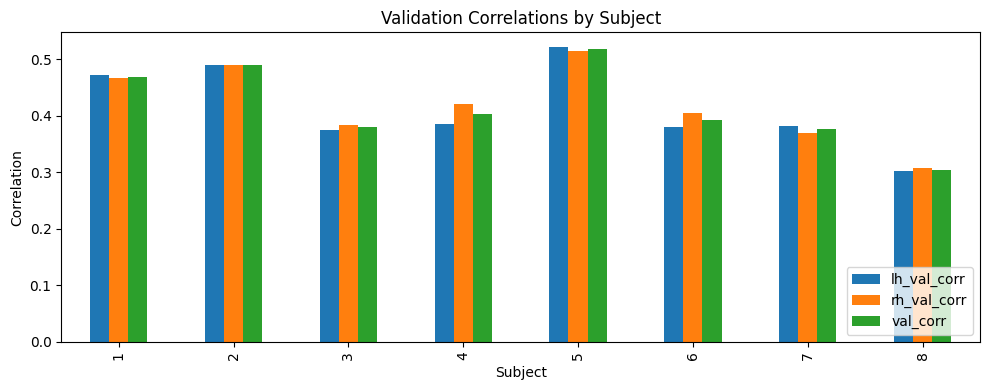

In [3]:
if summary_df.empty:
    print("No metrics available for plotting.")
else:
    metric_columns = ["lh_val_corr", "rh_val_corr", "val_corr"]
    plot_df = summary_df[["subject", *metric_columns]].dropna()
    if plot_df.empty:
        print("Validation correlation values are missing.")
    else:
        ax = plot_df.set_index("subject").plot(kind="bar", figsize=(10, 4))
        ax.set_title("Validation Correlations by Subject")
        ax.set_xlabel("Subject")
        ax.set_ylabel("Correlation")
        ax.legend(loc="lower right")
        plt.tight_layout()

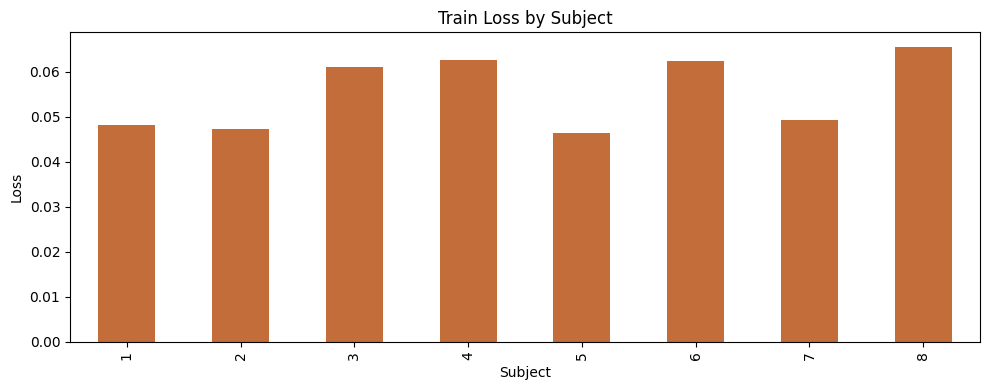

In [4]:
if summary_df.empty or "train_loss" not in summary_df:
    print("Train loss is not available.")
else:
    plot_df = summary_df[["subject", "train_loss"]].dropna()
    if plot_df.empty:
        print("Train loss values are missing.")
    else:
        ax = plot_df.plot(x="subject", y="train_loss", kind="bar", figsize=(10, 4), legend=False, color="#c26d3a")
        ax.set_title("Train Loss by Subject")
        ax.set_xlabel("Subject")
        ax.set_ylabel("Loss")
        plt.tight_layout()

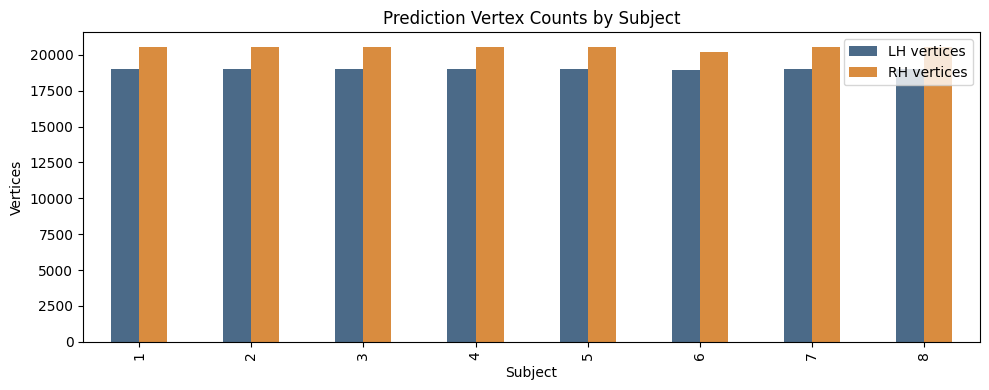

In [5]:
required = {"subject", "lh_vertices", "rh_vertices"}
if summary_df.empty or not required.issubset(summary_df.columns):
    print("Prediction-shape data is not available for plotting.")
else:
    plot_df = summary_df[["subject", "lh_vertices", "rh_vertices"]].dropna()
    if plot_df.empty:
        print("Prediction vertex counts are missing.")
    else:
        ax = plot_df.set_index("subject").plot(kind="bar", figsize=(10, 4), color=["#4b6a88", "#d98c3f"])
        ax.set_title("Prediction Vertex Counts by Subject")
        ax.set_xlabel("Subject")
        ax.set_ylabel("Vertices")
        ax.legend(["LH vertices", "RH vertices"], loc="upper right")
        plt.tight_layout()